# Mondrian comparison: M00 vs M08

This notebook evaluates whether adopting **M08** as the new operational baseline is consistent not only with point-estimation metrics, but also with conformal efficiency and local validity.

Two comparisons are kept separate:

1. **Matched-configuration comparison**  
   M00 and M08 are evaluated with the same taxonomy, interval mode, number of bins, confidence level, calibration indices, and test indices.

2. **Best-system comparison**  
   The conservative and efficient selection policies are applied independently to each model. This measures the best valid conformal system obtainable from each predictor.

The primary decision criterion is:

> M08 should preserve nominal/global and local coverage while reducing interval width, especially in difficult regions and for `chi_eff`.

For `difficulty` taxonomy, each model uses its own embedding. Therefore, that comparison evaluates the complete predictor–representation–difficulty system. The `prediction` taxonomy is the cleaner controlled comparison of the point predictors.

## 1. Imports and paths

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import iqr

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

cwd = Path.cwd().resolve()

if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "cbc_pe" / "src").exists():
    PROJECT_ROOT = cwd / "cbc_pe"
else:
    raise RuntimeError(
        f"Could not locate project root from cwd={cwd}. Expected a src/ directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = Path("/data/vserrano/cbc_pe_data")
DATA_RESULTS = DATA_ROOT / "results"

DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"
RESULTS_DIR = DATA_RESULTS / DATASET_ID

LABEL_NAMES = ["chirp_mass", "total_mass", "chi_eff"]
CONFIDENCE_LEVEL = 0.90
N_NEIGHBORS = 5
MIN_SAMPLES_PER_BIN = 20

N_BINS_GRID = [4, 6, 8, 12, 16, 24, 32, 48]
TAXONOMY_MODES = ["prediction", "difficulty"]
INTERVAL_MODES = ["symmetric", "asymmetric"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("RESULTS_DIR exists:", RESULTS_DIR.exists())

PROJECT_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe
RESULTS_DIR: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000
RESULTS_DIR exists: True


## 2. Resolve M00 and M08 prediction files

The patterns are intentionally flexible because filenames changed during the experimental iterations. Review the selected files before continuing.

In [4]:
def resolve_file(root, patterns, description):
    if isinstance(patterns, (str, Path)):
        patterns = [patterns]

    matches = []
    for pattern in patterns:
        matches.extend(root.glob(str(pattern)))

    matches = sorted(set(matches), key=lambda p: p.stat().st_mtime)

    if not matches:
        raise FileNotFoundError(
            f"Could not find {description} in {root}.\nPatterns: {patterns}"
        )

    print(f"\n{description}:")
    for path in matches:
        print("  ", path.name)

    selected = matches[-1]
    print("Selected:", selected.name)
    return selected


RUNS = {
    "M00": {
        "label": "M00 baseline",
        "patterns": [
            f"{DATASET_ID}_SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123_train_val_cal_test_predictions_embeddings.npz",
        ],
    },
    "M08": {
        "label": "M08 residual dilated",
        "patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz",
        ],
    },
}

for model_id, run in RUNS.items():
    run["prediction_path"] = resolve_file(
        RESULTS_DIR,
        run["patterns"],
        f"{model_id} prediction file",
    )

assert "M08" not in RUNS["M08"]["prediction_path"].name
assert "seed124" not in RUNS["M08"]["prediction_path"].name

for model_id, run in RUNS.items():
    print(model_id, "->", run["prediction_path"].name)


M00 prediction file:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123_train_val_cal_test_predictions_embeddings.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123_train_val_cal_test_predictions_embeddings.npz

M08 prediction file:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz
M00 -> bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123_train_val_cal_test_predictions_embeddings.npz
M08 -> bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz


## 3. Load and align calibration/test arrays

In [5]:
def load_prediction_npz(path):
    with np.load(path, allow_pickle=True) as data:
        required = {
            "pred_cal", "y_cal", "emb_cal", "idx_cal",
            "pred_test", "y_test", "emb_test", "idx_test",
            "y_mean", "y_std",
        }
        missing = required.difference(data.files)
        if missing:
            raise KeyError(f"{path.name} missing keys: {sorted(missing)}")

        out = {key: np.asarray(data[key]) for key in data.files}

    if "label_names" in out:
        out["label_names"] = out["label_names"].tolist()
    else:
        out["label_names"] = LABEL_NAMES

    print(path.name)
    for key in [
        "pred_cal", "y_cal", "emb_cal", "idx_cal",
        "pred_test", "y_test", "emb_test", "idx_test",
    ]:
        print(f"  {key:12s}: {out[key].shape}")

    return out


RAW = {
    model_id: load_prediction_npz(run["prediction_path"])
    for model_id, run in RUNS.items()
}


def align_models(raw_by_model, split):
    common_idx = None

    for data in raw_by_model.values():
        idx = np.asarray(data[f"idx_{split}"], dtype=np.int64)
        common_idx = idx if common_idx is None else np.intersect1d(common_idx, idx)

    common_idx = np.sort(common_idx)
    aligned = {}

    for model_id, data in raw_by_model.items():
        idx = np.asarray(data[f"idx_{split}"], dtype=np.int64)
        order = np.argsort(idx)
        idx_sorted = idx[order]

        positions = np.searchsorted(idx_sorted, common_idx)
        if not np.array_equal(idx_sorted[positions], common_idx):
            raise RuntimeError(f"Index alignment failed for {model_id}, {split}")

        aligned[model_id] = {
            "idx": common_idx,
            "pred": np.asarray(data[f"pred_{split}"])[order][positions],
            "y": np.asarray(data[f"y_{split}"])[order][positions],
            "emb": np.asarray(data[f"emb_{split}"])[order][positions],
        }

    y_ref = aligned["M00"]["y"]
    for model_id in aligned:
        if not np.allclose(aligned[model_id]["y"], y_ref, rtol=1e-5, atol=1e-5):
            raise AssertionError(f"Aligned targets differ for {model_id}, {split}")

    return aligned


ALIGNED = {
    "cal": align_models(RAW, "cal"),
    "test": align_models(RAW, "test"),
}

for split in ["cal", "test"]:
    print(split, len(ALIGNED[split]["M00"]["idx"]))

y_mean = np.asarray(RAW["M00"]["y_mean"], dtype=float)
y_std = np.asarray(RAW["M00"]["y_std"], dtype=float)
label_names = RAW["M00"]["label_names"]

assert np.allclose(y_mean, RAW["M08"]["y_mean"])
assert np.allclose(y_std, RAW["M08"]["y_std"])
assert label_names == RAW["M08"]["label_names"]
assert label_names == LABEL_NAMES

for split in ["cal", "test"]:
    for model_id in RUNS:
        for name, array in ALIGNED[split][model_id].items():
            if name != "idx":
                assert np.all(np.isfinite(array)), f"{model_id}/{split}/{name} not finite"

print("Alignment and sanity checks passed.")

bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123_train_val_cal_test_predictions_embeddings.npz
  pred_cal    : (30000, 3)
  y_cal       : (30000, 3)
  emb_cal     : (30000, 64)
  idx_cal     : (30000,)
  pred_test   : (30000, 3)
  y_test      : (30000, 3)
  emb_test    : (30000, 64)
  idx_test    : (30000,)
bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz
  pred_cal    : (30000, 3)
  y_cal       : (30000, 3)
  emb_cal     : (30000, 64)
  idx_cal     : (30000,)
  pred_test   : (30000, 3)
  y_test      : (30000, 3)
  emb_test    : (30000, 64)
  idx_test    : (30000,)
cal 30000
test 30000
Alignment and sanity checks passed.


## 4. Physical-space setup

In [7]:
def inverse_standardize(values):
    return values * y_std + y_mean

y_test_phys = inverse_standardize(ALIGNED["test"]["M00"]["y"])

label_ranges_phys = {
    label: np.ptp(y_test_phys[:, j])
    for j, label in enumerate(label_names)
}

print("y_mean:", y_mean)
print("y_std:", y_std)
print("label physical ranges:", label_ranges_phys)

y_mean: [3.74526215e+01 9.49739685e+01 1.02269521e-03]
y_std: [16.48472214 34.65016556  0.44085518]
label physical ranges: {'chirp_mass': np.float64(73.19801743155358), 'total_mass': np.float64(168.15349200911987), 'chi_eff': np.float64(1.9890720543515883)}


## 5. Global conformal control

Before introducing Mondrian bins, compare ordinary split conformal intervals. This is a sanity check: the better point predictor should generally require smaller residual quantiles at comparable coverage.

In [8]:
def conformal_order_statistic(values, confidence_level):
    values = np.sort(np.asarray(values))
    n = len(values)
    k = int(np.ceil((n + 1) * confidence_level)) - 1
    k = int(np.clip(k, 0, n - 1))
    return values[k]


def global_symmetric_conformal(pred_cal, y_cal, pred_test, y_test, confidence_level):
    n_labels = y_cal.shape[1]
    lower = np.empty_like(pred_test)
    upper = np.empty_like(pred_test)
    quantiles = np.empty(n_labels)

    for j in range(n_labels):
        scores = np.abs(y_cal[:, j] - pred_cal[:, j])
        q = conformal_order_statistic(scores, confidence_level)
        quantiles[j] = q
        lower[:, j] = pred_test[:, j] - q
        upper[:, j] = pred_test[:, j] + q

    covered = (y_test >= lower) & (y_test <= upper)
    widths = upper - lower

    return {
        "lower": lower,
        "upper": upper,
        "quantiles": quantiles,
        "coverage": covered.mean(axis=0),
        "widths": widths,
    }


global_rows = []
GLOBAL_RESULTS = {}

for model_id in RUNS:
    result = global_symmetric_conformal(
        pred_cal=ALIGNED["cal"][model_id]["pred"],
        y_cal=ALIGNED["cal"][model_id]["y"],
        pred_test=ALIGNED["test"][model_id]["pred"],
        y_test=ALIGNED["test"][model_id]["y"],
        confidence_level=CONFIDENCE_LEVEL,
    )
    GLOBAL_RESULTS[model_id] = result

    widths_phys = result["widths"] * y_std

    for j, label in enumerate(label_names):
        global_rows.append({
            "model": model_id,
            "label": label,
            "coverage": result["coverage"][j],
            "mean_width_phys": np.mean(widths_phys[:, j]),
            "median_width_phys": np.median(widths_phys[:, j]),
            "q90_width_phys": np.quantile(widths_phys[:, j], 0.90),
            "q95_width_phys": np.quantile(widths_phys[:, j], 0.95),
            "score_quantile_std": result["quantiles"][j],
        })

global_conformal_df = pd.DataFrame(global_rows)
display(global_conformal_df)

global_pivot = global_conformal_df.pivot(index="label", columns="model")
global_delta_rows = []

for label in label_names:
    global_delta_rows.append({
        "label": label,
        "coverage_M00": global_pivot.loc[label, ("coverage", "M00")],
        "coverage_M08": global_pivot.loc[label, ("coverage", "M08")],
        "coverage_delta_M08_minus_M00": (
            global_pivot.loc[label, ("coverage", "M08")]
            - global_pivot.loc[label, ("coverage", "M00")]
        ),
        "median_width_M00": global_pivot.loc[label, ("median_width_phys", "M00")],
        "median_width_M08": global_pivot.loc[label, ("median_width_phys", "M08")],
        "median_width_delta_pct": 100 * (
            global_pivot.loc[label, ("median_width_phys", "M08")]
            - global_pivot.loc[label, ("median_width_phys", "M00")]
        ) / global_pivot.loc[label, ("median_width_phys", "M00")],
    })

global_conformal_delta_df = pd.DataFrame(global_delta_rows)
display(global_conformal_delta_df)

,model,label,coverage,mean_width_phys,median_width_phys,q90_width_phys,q95_width_phys,score_quantile_std
0,M00,chirp_mass,0.903033,17.679308,17.679308,17.679310,17.679310,0.536233
1,M00,total_mass,0.902867,33.066043,33.066043,33.066045,33.066047,0.477141
2,M00,chi_eff,0.898167,0.655967,0.655967,0.655967,0.655967,0.743971
3,M08,chirp_mass,0.898100,15.935310,15.935311,15.935311,15.935311,0.483336
4,M08,total_mass,0.900967,30.138082,30.138081,30.138085,30.138085,0.434891
5,M08,chi_eff,0.899767,0.600533,0.600533,0.600533,0.600533,0.681100


,label,coverage_M00,coverage_M08,coverage_delta_M08_minus_M00,median_width_M00,median_width_M08,median_width_delta_pct
0,chirp_mass,0.903033,0.898100,-0.004933,17.679308,15.935311,-9.864626
1,total_mass,0.902867,0.900967,-0.001900,33.066043,30.138081,-8.854891
2,chi_eff,0.898167,0.899767,0.001600,0.655967,0.600533,-8.450786


## 6. Run the identical Mondrian grid for both models

The grid is identical for both predictors. Results are stored with model-aware keys:

```python
(model, taxonomy_mode, interval_mode, n_bins)
```

In [9]:
from src.conformal.pipeline import run_mondrian_regression

all_results = {}
summary_rows = []

for model_id in RUNS:
    pred_cal = ALIGNED["cal"][model_id]["pred"]
    y_cal = ALIGNED["cal"][model_id]["y"]
    emb_cal = ALIGNED["cal"][model_id]["emb"]

    pred_test = ALIGNED["test"][model_id]["pred"]
    y_test = ALIGNED["test"][model_id]["y"]
    emb_test = ALIGNED["test"][model_id]["emb"]

    for taxonomy_mode in TAXONOMY_MODES:
        for interval_mode in INTERVAL_MODES:
            for n_bins in N_BINS_GRID:
                kwargs = dict(
                    pred_cal=pred_cal,
                    pred_test=pred_test,
                    y_cal=y_cal,
                    y_test=y_test,
                    n_bins=n_bins,
                    confidence_level=CONFIDENCE_LEVEL,
                    apply_jitter=True,
                    interval_mode=interval_mode,
                    taxonomy_mode=taxonomy_mode,
                    min_samples_per_bin=MIN_SAMPLES_PER_BIN,
                    tolerance_sigmas=(1, 2, 3),
                )

                if taxonomy_mode == "difficulty":
                    kwargs.update(
                        cal_embedding=emb_cal,
                        target_embedding=emb_test,
                        n_neighbors=N_NEIGHBORS,
                    )

                result = run_mondrian_regression(**kwargs)
                key = (model_id, taxonomy_mode, interval_mode, n_bins)
                all_results[key] = result

                metrics = result.metrics
                widths_std = result.upper - result.lower
                widths_phys = widths_std * y_std

                for j, label in enumerate(label_names):
                    coverage_bin = metrics["coverage_per_bin"][:, j]
                    count_bin = metrics["counts_per_bin"][:, j]
                    valid_bins = count_bin > 0

                    bin_tol = metrics["bin_tolerance_normal"]
                    low_2s = bin_tol["2sigma_low"][:, j]
                    high_2s = bin_tol["2sigma_high"][:, j]
                    width_2s = bin_tol["2sigma_width"][:, j]

                    within_2s = (
                        (coverage_bin >= low_2s)
                        & (coverage_bin <= high_2s)
                        & valid_bins
                    )
                    under_2s = (coverage_bin < low_2s) & valid_bins
                    over_2s = (coverage_bin > high_2s) & valid_bins

                    n_bad_bins_p005 = int(
                        np.nansum(
                            metrics["bin_undercoverage_pvalue"][:, j] < 0.05
                        )
                    )

                    row = {
                        "model": model_id,
                        "taxonomy_mode": taxonomy_mode,
                        "interval_mode": interval_mode,
                        "n_bins": n_bins,
                        "label": label,
                        "label_index": j,
                        "n_samples": int(metrics["n_samples_per_label"][j]),
                        "covered_count": int(metrics["covered_count_global"][j]),
                        "global_coverage": metrics["global_coverage"][j],
                        "miscoverage": metrics["miscoverage"][j],
                        "global_coverage_gap": metrics["global_coverage_gap"][j],
                        "global_undercoverage_pvalue": (
                            metrics["global_undercoverage_pvalue"][j]
                        ),
                        "global_mean_width_std": metrics["global_mean_width"][j],
                        "global_median_width_std": (
                            metrics["global_median_width"][j]
                        ),
                        "global_mean_width_phys": np.mean(widths_phys[:, j]),
                        "global_median_width_phys": np.median(widths_phys[:, j]),
                        "global_iqr_width_phys": iqr(widths_phys[:, j]),
                        "global_q90_width_phys": np.quantile(widths_phys[:, j], 0.90),
                        "global_q95_width_phys": np.quantile(widths_phys[:, j], 0.95),
                        "normalized_median_width_range": (
                            np.median(widths_phys[:, j])
                            / label_ranges_phys[label]
                        ),
                        "min_coverage_per_bin": (
                            metrics["min_coverage_per_label"][j]
                        ),
                        "max_undercoverage_gap": (
                            metrics["max_undercoverage_gap"][j]
                        ),
                        "min_count_per_bin": int(
                            np.nanmin(metrics["counts_per_bin"][:, j])
                        ),
                        "max_count_per_bin": int(
                            np.nanmax(metrics["counts_per_bin"][:, j])
                        ),
                        "n_bad_bins_p005": n_bad_bins_p005,
                        "bad_bin_fraction": n_bad_bins_p005 / n_bins,
                        "all_bins_within_2sigma": bool(
                            np.all(within_2s[valid_bins])
                        ),
                        "n_bins_outside_2sigma": int(
                            np.sum(~within_2s[valid_bins])
                        ),
                        "outside_bin_fraction_2sigma": float(
                            np.mean(~within_2s[valid_bins])
                        ),
                        "n_bins_under_2sigma": int(
                            np.sum(under_2s[valid_bins])
                        ),
                        "under_bin_fraction_2sigma": float(
                            np.mean(under_2s[valid_bins])
                        ),
                        "n_bins_over_2sigma": int(
                            np.sum(over_2s[valid_bins])
                        ),
                        "over_bin_fraction_2sigma": float(
                            np.mean(over_2s[valid_bins])
                        ),
                        "median_bin_2sigma_width": float(
                            np.nanmedian(width_2s[valid_bins])
                        ),
                        "global_lower_miss_rate": (
                            metrics["global_lower_miss_rate"][j]
                        ),
                        "global_upper_miss_rate": (
                            metrics["global_upper_miss_rate"][j]
                        ),
                        "global_tail_miss_imbalance": (
                            metrics["global_tail_miss_imbalance"][j]
                        ),
                    }

                    global_tol = metrics["global_tolerance_normal"]
                    for k in [1, 2, 3]:
                        low = global_tol[f"{k}sigma_low"][j]
                        high = global_tol[f"{k}sigma_high"][j]
                        width = global_tol[f"{k}sigma_width"][j]

                        row[f"global_tol_{k}sigma_low"] = low
                        row[f"global_tol_{k}sigma_high"] = high
                        row[f"global_tol_{k}sigma_width"] = width
                        row[f"global_within_{k}sigma"] = bool(
                            low <= metrics["global_coverage"][j] <= high
                        )

                    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

print("summary_df shape:", summary_df.shape)
display(summary_df.head())

summary_df shape: (192, 49)


,model,taxonomy_mode,interval_mode,n_bins,label,label_index,n_samples,covered_count,global_coverage,miscoverage,global_coverage_gap,global_undercoverage_pvalue,global_mean_width_std,global_median_width_std,global_mean_width_phys,global_median_width_phys,global_iqr_width_phys,global_q90_width_phys,global_q95_width_phys,normalized_median_width_range,min_coverage_per_bin,max_undercoverage_gap,min_count_per_bin,max_count_per_bin,n_bad_bins_p005,bad_bin_fraction,all_bins_within_2sigma,n_bins_outside_2sigma,outside_bin_fraction_2sigma,n_bins_under_2sigma,under_bin_fraction_2sigma,n_bins_over_2sigma,over_bin_fraction_2sigma,median_bin_2sigma_width,global_lower_miss_rate,global_upper_miss_rate,global_tail_miss_imbalance,global_tol_1sigma_low,global_tol_1sigma_high,global_tol_1sigma_width,global_within_1sigma,global_tol_2sigma_low,global_tol_2sigma_high,global_tol_2sigma_width,global_within_2sigma,global_tol_3sigma_low,global_tol_3sigma_high,global_tol_3sigma_width,global_within_3sigma
0,M00,prediction,symmetric,4,chirp_mass,0,30000,27072,0.902400,0.097600,0.002400,0.918903,1.029727,0.971662,16.974760,16.017577,11.650711,21.601476,21.601476,0.218825,0.899128,0.000872,7429,7572,0,0.000000,True,0,0.000000,0,0.000000,0,0.000000,0.006929,0.049967,0.047633,0.002333,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
1,M00,prediction,symmetric,4,total_mass,1,30000,27098,0.903267,0.096733,0.003267,0.971441,0.938866,0.851267,32.531845,29.496558,4.612983,37.305149,37.305149,0.175414,0.901239,0.000000,7420,7584,0,0.000000,True,0,0.000000,0,0.000000,0,0.000000,0.006929,0.037067,0.059667,0.022600,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
2,M00,prediction,symmetric,4,chi_eff,2,30000,26924,0.897467,0.102533,0.002533,0.073503,1.497747,1.416719,0.660289,0.624568,0.205515,0.762137,0.762137,0.314000,0.892031,0.007969,7391,7613,1,0.250000,False,1,0.250000,1,0.250000,0,0.000000,0.006929,0.049067,0.053467,0.004400,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
3,M00,prediction,symmetric,6,chirp_mass,0,30000,27079,0.902633,0.097367,0.002633,0.937420,1.036094,1.071030,17.079718,17.655627,8.419937,22.600828,22.600828,0.241204,0.895912,0.004088,4895,5076,0,0.000000,True,0,0.000000,0,0.000000,0,0.000000,0.008478,0.051100,0.046267,0.004833,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
4,M00,prediction,symmetric,6,total_mass,1,30000,27114,0.903800,0.096200,0.003800,0.986573,0.939620,0.874892,32.557984,30.315136,7.805594,37.652322,37.652322,0.180283,0.898135,0.001865,4927,5095,0,0.000000,True,0,0.000000,0,0.000000,0,0.000000,0.008493,0.036567,0.059633,0.023067,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,False,0.894804,0.905196,0.005196,True


In [19]:
display(summary_df.head(10))

,model,taxonomy_mode,interval_mode,n_bins,label,label_index,n_samples,covered_count,global_coverage,miscoverage,global_coverage_gap,global_undercoverage_pvalue,global_mean_width_std,global_median_width_std,global_mean_width_phys,global_median_width_phys,global_iqr_width_phys,global_q90_width_phys,global_q95_width_phys,normalized_median_width_range,min_coverage_per_bin,max_undercoverage_gap,min_count_per_bin,max_count_per_bin,n_bad_bins_p005,bad_bin_fraction,all_bins_within_2sigma,n_bins_outside_2sigma,outside_bin_fraction_2sigma,n_bins_under_2sigma,under_bin_fraction_2sigma,n_bins_over_2sigma,over_bin_fraction_2sigma,median_bin_2sigma_width,global_lower_miss_rate,global_upper_miss_rate,global_tail_miss_imbalance,global_tol_1sigma_low,global_tol_1sigma_high,global_tol_1sigma_width,global_within_1sigma,global_tol_2sigma_low,global_tol_2sigma_high,global_tol_2sigma_width,global_within_2sigma,global_tol_3sigma_low,global_tol_3sigma_high,global_tol_3sigma_width,global_within_3sigma
0,M00,prediction,symmetric,4,chirp_mass,0,30000,27072,0.902400,0.097600,0.002400,0.918903,1.029727,0.971662,16.974760,16.017577,11.650711,21.601476,21.601476,0.218825,0.899128,0.000872,7429,7572,0,0.000000,True,0,0.000000,0,0.000000,0,0.000000,0.006929,0.049967,0.047633,0.002333,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
1,M00,prediction,symmetric,4,total_mass,1,30000,27098,0.903267,0.096733,0.003267,0.971441,0.938866,0.851267,32.531845,29.496558,4.612983,37.305149,37.305149,0.175414,0.901239,0.000000,7420,7584,0,0.000000,True,0,0.000000,0,0.000000,0,0.000000,0.006929,0.037067,0.059667,0.022600,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
2,M00,prediction,symmetric,4,chi_eff,2,30000,26924,0.897467,0.102533,0.002533,0.073503,1.497747,1.416719,0.660289,0.624568,0.205515,0.762137,0.762137,0.314000,0.892031,0.007969,7391,7613,1,0.250000,False,1,0.250000,1,0.250000,0,0.000000,0.006929,0.049067,0.053467,0.004400,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
3,M00,prediction,symmetric,6,chirp_mass,0,30000,27079,0.902633,0.097367,0.002633,0.937420,1.036094,1.071030,17.079718,17.655627,8.419937,22.600828,22.600828,0.241204,0.895912,0.004088,4895,5076,0,0.000000,True,0,0.000000,0,0.000000,0,0.000000,0.008478,0.051100,0.046267,0.004833,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
4,M00,prediction,symmetric,6,total_mass,1,30000,27114,0.903800,0.096200,0.003800,0.986573,0.939620,0.874892,32.557984,30.315136,7.805594,37.652322,37.652322,0.180283,0.898135,0.001865,4927,5095,0,0.000000,True,0,0.000000,0,0.000000,0,0.000000,0.008493,0.036567,0.059633,0.023067,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,False,0.894804,0.905196,0.005196,True
5,M00,prediction,symmetric,6,chi_eff,2,30000,26970,0.899000,0.101000,0.001000,0.284520,1.500283,1.584255,0.661407,0.698427,0.100335,0.758501,0.758501,0.351132,0.891721,0.008279,4904,5152,1,0.166667,True,0,0.000000,0,0.000000,0,0.000000,0.008507,0.048333,0.052667,0.004333,0.898268,0.901732,0.001732,True,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
6,M00,prediction,symmetric,8,chirp_mass,0,30000,27103,0.903433,0.096567,0.003433,0.977229,1.033350,1.102394,17.034492,18.172653,9.519166,22.474507,22.474507,0.248267,0.898069,0.001931,3613,3874,0,0.000000,False,1,0.125000,0,0.000000,1,0.125000,0.009819,0.050133,0.046433,0.003700,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
7,M00,prediction,symmetric,8,total_mass,1,30000,27113,0.903767,0.096233,0.003767,0.985888,0.939184,0.896115,32.542897,31.050544,6.917059,38.333887,38.333887,0.184656,0.890289,0.009711,3579,3841,1,0.125000,False,3,0.375000,0,0.000000,3,0.375000,0.009760,0.036933,0.059300,0.022367,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,False,0.894804,0.905196,0.005196,True
8,M00,pre

## 7. Matched-configuration comparison

This is the primary controlled test. Each M00 row is paired with the M08 row having exactly the same:

- taxonomy;
- interval mode;
- number of bins;
- target label.

In [20]:
MATCH_KEYS = ["taxonomy_mode", "interval_mode", "n_bins", "label"]

m00 = (
    summary_df.query("model == 'M00'")
    .drop(columns="model")
    .add_suffix("_M00")
    .rename(columns={f"{key}_M00": key for key in MATCH_KEYS})
)

m08 = (
    summary_df.query("model == 'M08'")
    .drop(columns="model")
    .add_suffix("_M08")
    .rename(columns={f"{key}_M08": key for key in MATCH_KEYS})
)

matched_df = m00.merge(
    m08,
    on=MATCH_KEYS,
    how="inner",
    validate="one_to_one",
)

for metric in [
    "global_coverage",
    "global_median_width_phys",
    "global_mean_width_phys",
    "global_q90_width_phys",
    "global_q95_width_phys",
    "min_coverage_per_bin",
    "max_undercoverage_gap",
    "under_bin_fraction_2sigma",
    "global_tail_miss_imbalance",
]:
    matched_df[f"{metric}_delta_M08_minus_M00"] = (
        matched_df[f"{metric}_M08"] - matched_df[f"{metric}_M00"]
    )

for metric in [
    "global_median_width_phys",
    "global_mean_width_phys",
    "global_q90_width_phys",
    "global_q95_width_phys",
]:
    matched_df[f"{metric}_delta_pct"] = 100 * (
        matched_df[f"{metric}_M08"] - matched_df[f"{metric}_M00"]
    ) / matched_df[f"{metric}_M00"]

matched_df["both_global_within_2sigma"] = (
    matched_df["global_within_2sigma_M00"]
    & matched_df["global_within_2sigma_M08"]
)

matched_df["both_min_count_ok"] = (
    (matched_df["min_count_per_bin_M00"] >= 200)
    & (matched_df["min_count_per_bin_M08"] >= 200)
)

matched_df["both_locally_efficient"] = (
    matched_df["both_global_within_2sigma"]
    & matched_df["both_min_count_ok"]
    & (matched_df["under_bin_fraction_2sigma_M00"] <= 0.10)
    & (matched_df["under_bin_fraction_2sigma_M08"] <= 0.10)
    & (matched_df["max_undercoverage_gap_M00"] <= 0.05)
    & (matched_df["max_undercoverage_gap_M08"] <= 0.05)
)

display(
    matched_df[
        MATCH_KEYS + [
            "global_coverage_M00",
            "global_coverage_M08",
            "global_median_width_phys_M00",
            "global_median_width_phys_M08",
            "global_median_width_phys_delta_pct",
            "both_global_within_2sigma",
            "under_bin_fraction_2sigma_M00",
            "under_bin_fraction_2sigma_M08",
        ]
    ].head(21)
)

,taxonomy_mode,interval_mode,n_bins,label,global_coverage_M00,global_coverage_M08,global_median_width_phys_M00,global_median_width_phys_M08,global_median_width_phys_delta_pct,both_global_within_2sigma,under_bin_fraction_2sigma_M00,under_bin_fraction_2sigma_M08
0,prediction,symmetric,4,chirp_mass,0.902400,0.902100,16.017577,19.679241,22.860286,True,0.000000,0.000000
1,prediction,symmetric,4,total_mass,0.903267,0.901400,29.496558,32.008953,8.517585,True,0.000000,0.000000
2,prediction,symmetric,4,chi_eff,0.897467,0.900233,0.624568,0.608626,-2.552520,True,0.250000,0.250000
3,prediction,symmetric,6,chirp_mass,0.902633,0.902200,17.655627,18.615762,5.438125,True,0.000000,0.000000
4,prediction,symmetric,6,total_mass,0.903800,0.901867,30.315136,30.410741,0.315370,False,0.000000,0.000000
5,prediction,symmetric,6,chi_eff,0.899000,0.899733,0.698427,0.622837,-10.822813,True,0.000000,0.166667
6,prediction,symmetric,8,chirp_mass,0.903433,0.903667,18.172653,17.954527,-1.200297,False,0.000000,0.000000
7,prediction,symmetric,8,total_mass,0.903767,0.902100,31.050544,29.633779,-4.562769,False,0.000000,0.000000
8,prediction,symmetric,8,chi_eff,0.898267,0.900633,0.679038,0.602634,-11.251699,True,0.250000,0.125000
9,prediction,symmetric,12,chirp_mass,0.902533,0.902500,16.571439,16.149321,-2.547263,True,0.000000,0.000000


## 8. Aggregate matched-grid evidence

The table below reports, for valid paired configurations:

- fraction of configurations where M08 intervals are narrower;
- median and best/worst width change;
- coverage change;
- changes in local undercoverage diagnostics.

Prediction and difficulty taxonomies are reported separately.

In [11]:
aggregate_rows = []

for taxonomy_mode in TAXONOMY_MODES:
    for interval_mode in INTERVAL_MODES:
        for label in label_names:
            sub = matched_df[
                (matched_df["taxonomy_mode"] == taxonomy_mode)
                & (matched_df["interval_mode"] == interval_mode)
                & (matched_df["label"] == label)
                & matched_df["both_global_within_2sigma"]
                & matched_df["both_min_count_ok"]
            ].copy()

            if sub.empty:
                continue

            width_delta = sub["global_median_width_phys_delta_pct"]

            aggregate_rows.append({
                "taxonomy_mode": taxonomy_mode,
                "interval_mode": interval_mode,
                "label": label,
                "n_valid_matched_configs": len(sub),
                "fraction_M08_narrower": np.mean(width_delta < 0),
                "median_width_delta_pct": np.median(width_delta),
                "min_width_delta_pct": np.min(width_delta),
                "max_width_delta_pct": np.max(width_delta),
                "median_coverage_delta": np.median(
                    sub["global_coverage_delta_M08_minus_M00"]
                ),
                "median_min_bin_coverage_delta": np.median(
                    sub["min_coverage_per_bin_delta_M08_minus_M00"]
                ),
                "median_under_bin_fraction_delta": np.median(
                    sub["under_bin_fraction_2sigma_delta_M08_minus_M00"]
                ),
                "fraction_both_locally_efficient": np.mean(
                    sub["both_locally_efficient"]
                ),
            })

matched_grid_summary_df = pd.DataFrame(aggregate_rows)
display(matched_grid_summary_df)

,taxonomy_mode,interval_mode,label,n_valid_matched_configs,fraction_M08_narrower,median_width_delta_pct,min_width_delta_pct,max_width_delta_pct,median_coverage_delta,median_min_bin_coverage_delta,median_under_bin_fraction_delta,fraction_both_locally_efficient
0,prediction,symmetric,chirp_mass,5,0.600000,-2.547263,-16.883467,22.860286,-0.000300,-0.003041,0.000000,1.000000
1,prediction,symmetric,total_mass,4,0.750000,-9.366082,-10.782638,8.517585,-0.001850,-0.000711,0.000000,1.000000
2,prediction,symmetric,chi_eff,8,1.000000,-8.798126,-11.251699,-2.552520,0.001600,-0.001604,0.000000,0.000000
3,prediction,asymmetric,chirp_mass,5,0.600000,-4.299085,-14.209177,21.169591,0.000033,-0.003406,0.000000,0.800000
4,prediction,asymmetric,total_mass,8,0.875000,-10.072503,-12.480462,4.119154,-0.000400,-0.001592,0.000000,1.000000
5,prediction,asymmetric,chi_eff,8,1.000000,-7.475219,-11.317515,-3.287734,0.000900,-0.001789,0.000000,0.125000
6,difficulty,symmetric,chirp_mass,8,0.625000,-3.564711,-6.408746,17.436906,0.002017,-0.001806,-0.010417,0.625000
7,difficulty,symmetric,total_mass,7,0.571429,-2.210451,-6.548086,10.872880,-0.000700,-0.005252,0.031250,0.857143
8,difficulty,symmetric,chi_eff,8,1.000000,-7.753617,-10.360073,-5.248494,-0.000917,0.003798,0.000000,0.125000
9,difficulty,asymmetric,chirp_mass,8,0.625000,-2.633060,-6.859131,17.068785,0.002883,-0.003386,-0.031250,0.375000


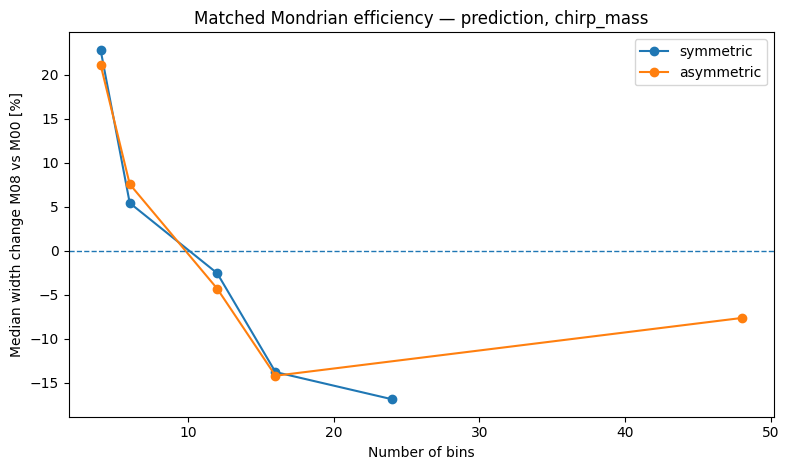

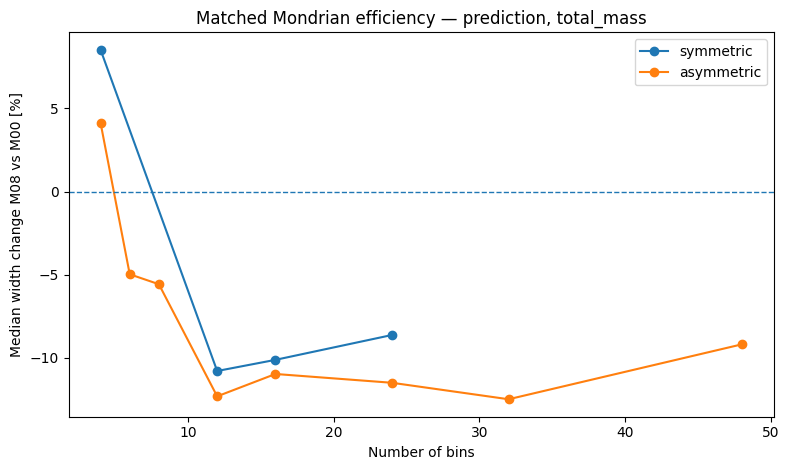

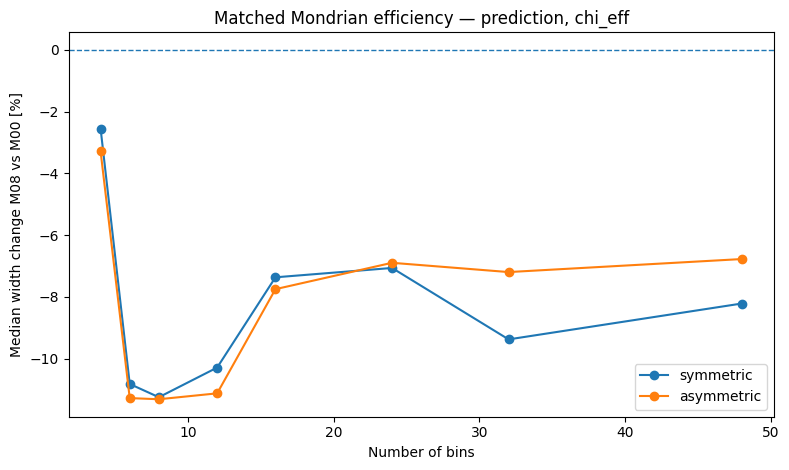

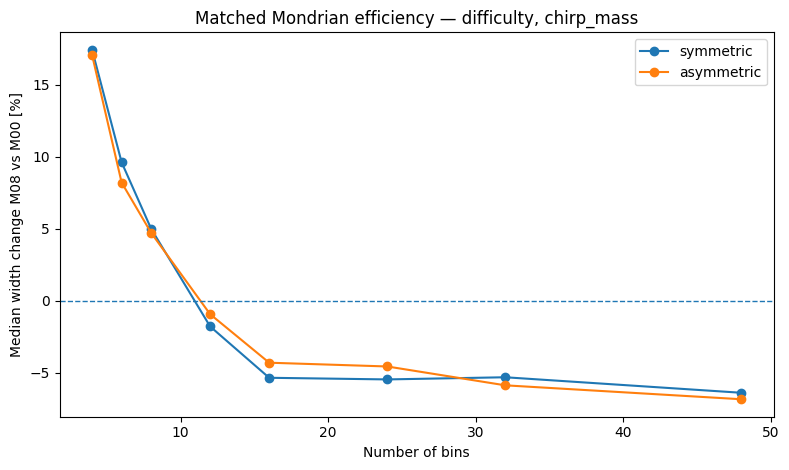

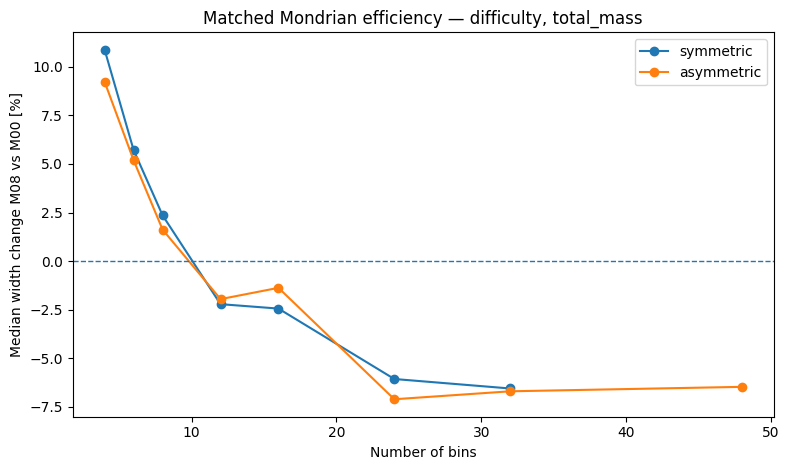

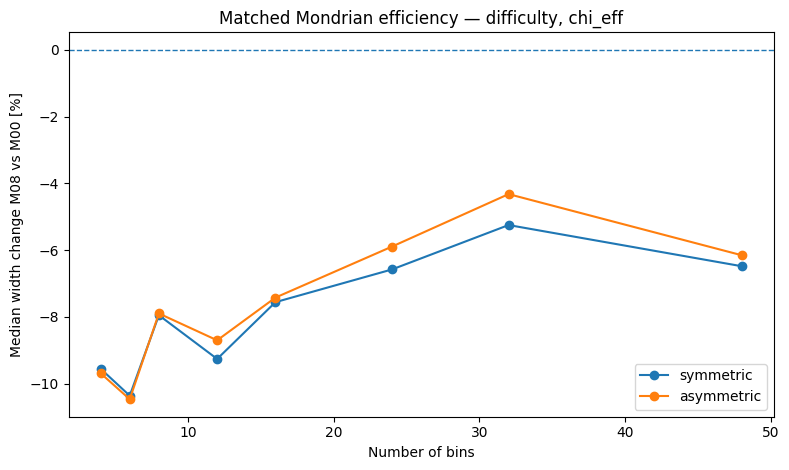

In [12]:
for taxonomy_mode in TAXONOMY_MODES:
    for label in label_names:
        sub = matched_df[
            (matched_df["taxonomy_mode"] == taxonomy_mode)
            & (matched_df["label"] == label)
            & matched_df["both_global_within_2sigma"]
            & matched_df["both_min_count_ok"]
        ].copy()

        if sub.empty:
            continue

        plt.figure(figsize=(8.0, 4.8))

        for interval_mode in INTERVAL_MODES:
            s = sub[sub["interval_mode"] == interval_mode].sort_values("n_bins")
            plt.plot(
                s["n_bins"],
                s["global_median_width_phys_delta_pct"],
                marker="o",
                label=interval_mode,
            )

        plt.axhline(0, linestyle="--", linewidth=1)
        plt.xlabel("Number of bins")
        plt.ylabel("Median width change M08 vs M00 [%]")
        plt.title(f"Matched Mondrian efficiency — {taxonomy_mode}, {label}")
        plt.legend()
        plt.tight_layout()
        plt.show()

## 9. Conservative and efficient selection per model

The same policies used in the original notebook are applied independently to M00 and M08.

This answers a different question from the matched comparison:

> What is the best valid conformal system each predictor can support?

In [13]:
MIN_COUNT_PER_BIN = 200
WIDTH_TIE_FRACTION = 0.02
MAX_UNDER_BIN_FRACTION_EFFICIENT = 0.10
MAX_UNDERCOVERAGE_GAP_EFFICIENT = 0.05
TOP_K = 5


def get_base_candidates(model_summary, label):
    return model_summary[
        (model_summary["label"] == label)
        & model_summary["global_within_2sigma"]
        & (model_summary["min_count_per_bin"] >= MIN_COUNT_PER_BIN)
    ].copy()


def select_conservative(model_summary, label):
    candidates = get_base_candidates(model_summary, label)

    if candidates.empty:
        raise ValueError(f"No globally valid candidates for label={label}")

    zero_under = candidates[
        candidates["n_bins_under_2sigma"] == 0
    ].copy()

    if not zero_under.empty:
        pool = zero_under
        policy = "conservative_zero_under_bins_2sigma"
    else:
        min_under = candidates["n_bins_under_2sigma"].min()
        pool = candidates[
            candidates["n_bins_under_2sigma"] == min_under
        ].copy()
        policy = "conservative_best_available"

    min_width = pool["global_median_width_phys"].min()
    width_limit = min_width * (1 + WIDTH_TIE_FRACTION)

    tied = pool[
        pool["global_median_width_phys"] <= width_limit
    ].copy()

    tied["min_width_for_label"] = min_width
    tied["width_limit"] = width_limit
    tied["relative_width_excess"] = (
        tied["global_median_width_phys"] / min_width - 1
    )

    ranked = tied.sort_values(
        [
            "n_bins",
            "max_undercoverage_gap",
            "global_tail_miss_imbalance",
            "global_median_width_phys",
        ],
        ascending=[False, True, True, True],
    )

    selected = ranked.iloc[0].copy()
    selected["selection_policy"] = policy
    return selected, ranked


def select_efficient(model_summary, label):
    candidates = get_base_candidates(model_summary, label)

    candidates = candidates[
        (candidates["under_bin_fraction_2sigma"]
         <= MAX_UNDER_BIN_FRACTION_EFFICIENT)
        & (candidates["max_undercoverage_gap"]
           <= MAX_UNDERCOVERAGE_GAP_EFFICIENT)
    ].copy()

    if candidates.empty:
        raise ValueError(f"No efficient candidates for label={label}")

    min_width = candidates["global_median_width_phys"].min()
    width_limit = min_width * (1 + WIDTH_TIE_FRACTION)

    tied = candidates[
        candidates["global_median_width_phys"] <= width_limit
    ].copy()

    tied["min_width_for_label"] = min_width
    tied["width_limit"] = width_limit
    tied["relative_width_excess"] = (
        tied["global_median_width_phys"] / min_width - 1
    )

    ranked = tied.sort_values(
        [
            "global_median_width_phys",
            "n_bins_under_2sigma",
            "max_undercoverage_gap",
            "global_tail_miss_imbalance",
            "n_bins",
        ],
        ascending=[True, True, True, True, False],
    )

    selected = ranked.iloc[0].copy()
    selected["selection_policy"] = "efficient"
    return selected, ranked

In [14]:
selection_rows = []
top_rows = []

for model_id in RUNS:
    model_summary = summary_df.query("model == @model_id").copy()

    for label in label_names:
        conservative, conservative_ranked = select_conservative(
            model_summary, label
        )
        efficient, efficient_ranked = select_efficient(
            model_summary, label
        )

        selection_rows.append(
            conservative.to_dict() | {"final_policy": "conservative"}
        )
        selection_rows.append(
            efficient.to_dict() | {"final_policy": "efficient"}
        )

        top_rows.append(
            conservative_ranked.head(TOP_K).assign(
                model=model_id,
                label=label,
                final_policy="conservative",
            )
        )
        top_rows.append(
            efficient_ranked.head(TOP_K).assign(
                model=model_id,
                label=label,
                final_policy="efficient",
            )
        )

selection_df = pd.DataFrame(selection_rows)
top_candidates_df = pd.concat(top_rows, ignore_index=True)

selection_display_cols = [
    "model",
    "final_policy",
    "label",
    "selection_policy",
    "taxonomy_mode",
    "interval_mode",
    "n_bins",
    "global_coverage",
    "min_coverage_per_bin",
    "n_bins_under_2sigma",
    "under_bin_fraction_2sigma",
    "max_undercoverage_gap",
    "global_median_width_phys",
    "global_q90_width_phys",
    "global_q95_width_phys",
    "global_tail_miss_imbalance",
    "min_count_per_bin",
]

display(
    selection_df[selection_display_cols]
    .sort_values(["label", "final_policy", "model"])
)

,model,final_policy,label,selection_policy,taxonomy_mode,interval_mode,n_bins,global_coverage,min_coverage_per_bin,n_bins_under_2sigma,under_bin_fraction_2sigma,max_undercoverage_gap,global_median_width_phys,global_q90_width_phys,global_q95_width_phys,global_tail_miss_imbalance,min_count_per_bin
4,M00,conservative,chi_eff,conservative_zero_under_bins_2sigma,difficulty,asymmetric,4,0.900233,0.893929,0,0.000000,0.006071,0.651478,0.893744,0.893744,0.002033,7307
10,M08,conservative,chi_eff,conservative_zero_under_bins_2sigma,difficulty,symmetric,6,0.898400,0.892167,0,0.000000,0.007833,0.576291,0.812271,0.812271,0.002067,4915
5,M00,efficient,chi_eff,efficient,difficulty,symmetric,32,0.899833,0.850746,3,0.093750,0.049254,0.607537,0.819855,1.061405,0.000167,852
11,M08,efficient,chi_eff,efficient,difficulty,symmetric,12,0.899067,0.882232,1,0.083333,0.017768,0.561315,0.721185,0.894796,0.002133,2401
0,M00,conservative,chirp_mass,conservative_zero_under_bins_2sigma,difficulty,symmetric,4,0.900700,0.896035,0,0.000000,0.003965,13.922626,25.640834,25.640834,0.003967,7298
6,M08,conservative,chirp_mass,conservative_zero_under_bins_2sigma,prediction,asymmetric,24,0.902767,0.886381,0,0.000000,0.013619,15.623656,21.191378,21.730857,0.000233,1170
1,M00,efficient,chirp_mass,efficient,difficulty,symmetric,4,0.900700,0.896035,0,0.000000,0.003965,13.922626,25.640834,25.640834,0.003967,7298
7,M08,efficient,chirp_mass,efficient,difficulty,symmetric,24,0.901567,0.873544,1,0.041667,0.026456,14.356512,23.366214,24.942036,0.002367,1150
2,M00,conservative,total_mass,conservative_zero_under_bins_2sigma,difficulty,symmetric,6,0.902633,0.895471,0,0.000000,0.004529,28.192608,47.880809,47.880809,0.028033,4946
8,M08,conservative,total_mass,conservative_zero_under_bins_2sigma,prediction,asymmetric,16,0.901067,0.887652,0,0.000000,0.012348,27.919006,37.565449,38.805998,0.001933,1792


## 10. Compare independently selected systems

A width reduction is meaningful only if the selected M08 configuration does not materially weaken global or local coverage.

In [15]:
selected_m00 = (
    selection_df.query("model == 'M00'")
    .drop(columns="model")
    .add_suffix("_M00")
    .rename(columns={
        "label_M00": "label",
        "final_policy_M00": "final_policy",
    })
)

selected_m08 = (
    selection_df.query("model == 'M08'")
    .drop(columns="model")
    .add_suffix("_M08")
    .rename(columns={
        "label_M08": "label",
        "final_policy_M08": "final_policy",
    })
)

selected_comparison_df = selected_m00.merge(
    selected_m08,
    on=["label", "final_policy"],
    validate="one_to_one",
)

for metric in [
    "global_coverage",
    "min_coverage_per_bin",
    "max_undercoverage_gap",
    "under_bin_fraction_2sigma",
    "global_median_width_phys",
    "global_q90_width_phys",
    "global_q95_width_phys",
    "global_tail_miss_imbalance",
]:
    selected_comparison_df[f"{metric}_delta_M08_minus_M00"] = (
        selected_comparison_df[f"{metric}_M08"]
        - selected_comparison_df[f"{metric}_M00"]
    )

for metric in [
    "global_median_width_phys",
    "global_q90_width_phys",
    "global_q95_width_phys",
]:
    selected_comparison_df[f"{metric}_delta_pct"] = 100 * (
        selected_comparison_df[f"{metric}_M08"]
        - selected_comparison_df[f"{metric}_M00"]
    ) / selected_comparison_df[f"{metric}_M00"]

selected_compare_cols = [
    "label",
    "final_policy",
    "taxonomy_mode_M00",
    "interval_mode_M00",
    "n_bins_M00",
    "taxonomy_mode_M08",
    "interval_mode_M08",
    "n_bins_M08",
    "global_coverage_M00",
    "global_coverage_M08",
    "min_coverage_per_bin_M00",
    "min_coverage_per_bin_M08",
    "n_bins_under_2sigma_M00",
    "n_bins_under_2sigma_M08",
    "global_median_width_phys_M00",
    "global_median_width_phys_M08",
    "global_median_width_phys_delta_pct",
    "global_q95_width_phys_delta_pct",
]

display(selected_comparison_df[selected_compare_cols])

,label,final_policy,taxonomy_mode_M00,interval_mode_M00,n_bins_M00,taxonomy_mode_M08,interval_mode_M08,n_bins_M08,global_coverage_M00,global_coverage_M08,min_coverage_per_bin_M00,min_coverage_per_bin_M08,n_bins_under_2sigma_M00,n_bins_under_2sigma_M08,global_median_width_phys_M00,global_median_width_phys_M08,global_median_width_phys_delta_pct,global_q95_width_phys_delta_pct
0,chirp_mass,conservative,difficulty,symmetric,4,prediction,asymmetric,24,0.900700,0.902767,0.896035,0.886381,0,0,13.922626,15.623656,12.217735,-15.249024
1,chirp_mass,efficient,difficulty,symmetric,4,difficulty,symmetric,24,0.900700,0.901567,0.896035,0.873544,0,1,13.922626,14.356512,3.116407,-2.725332
2,total_mass,conservative,difficulty,symmetric,6,prediction,asymmetric,16,0.902633,0.901067,0.895471,0.887652,0,0,28.192608,27.919006,-0.970475,-18.952918
3,total_mass,efficient,difficulty,symmetric,4,prediction,asymmetric,32,0.901467,0.901500,0.897741,0.874737,0,2,27.715133,27.286712,-1.545801,-14.447390
4,chi_eff,conservative,difficulty,asymmetric,4,difficulty,symmetric,6,0.900233,0.898400,0.893929,0.892167,0,0,0.651478,0.576291,-11.541017,-9.115882
5,chi_eff,efficient,difficulty,symmetric,32,difficulty,symmetric,12,0.899833,0.899067,0.850746,0.882232,3,1,0.607537,0.561315,-7.608077,-15.697041


## 11. Primary decision table

The decision combines four levels of evidence:

1. global conformal width;
2. prediction-taxonomy matched configurations;
3. difficulty-taxonomy matched systems;
4. independently selected conservative systems.

The cleanest causal evidence comes from **prediction taxonomy with matched configurations**. Difficulty results provide supporting system-level evidence.

In [ ]:
decision_rows = []

for label in label_names:
    global_row = global_conformal_delta_df.set_index("label").loc[label]

    pred_match = matched_df[
        (matched_df["label"] == label)
        & (matched_df["taxonomy_mode"] == "prediction")
        & matched_df["both_global_within_2sigma"]
        & matched_df["both_min_count_ok"]
    ]

    diff_match = matched_df[
        (matched_df["label"] == label)
        & (matched_df["taxonomy_mode"] == "difficulty")
        & matched_df["both_global_within_2sigma"]
        & matched_df["both_min_count_ok"]
    ]

    conservative = selected_comparison_df[
        (selected_comparison_df["label"] == label)
        & (selected_comparison_df["final_policy"] == "conservative")
    ].iloc[0]

    decision_rows.append({
        "label": label,
        "global_conformal_width_delta_pct": (n 2: predicciones medias-bajas
            global_row["median_width_delta_pct"]
        ),
        "global_conformal_coverage_delta": (
            global_row["coverage_delta_M08_minus_M00"]
        ),
        "prediction_n_matched_valid": len(pred_match),
        "prediction_fraction_M08_narrower": (
            np.mean(
                pred_match["global_median_width_phys_delta_pct"] < 0
            )
            if len(pred_match) else np.nan
        ),
        "prediction_median_width_delta_pct": (
            np.median(
                pred_match["global_median_width_phys_delta_pct"]
            )
            if len(pred_match) else np.nan
        ),
        "prediction_median_coverage_delta": (
            np.median(
                pred_match["global_coverage_delta_M08_minus_M00"]
            )
            if len(pred_match) else np.nan
        ),
        "difficulty_n_matched_valid": len(diff_match),
        "difficulty_fraction_M08_narrower": (
            np.mean(
                diff_match["global_median_width_phys_delta_pct"] < 0
            )
            if len(diff_match) else np.nan
        ),
        "difficulty_median_width_delta_pct": (
            np.median(
                diff_match["global_median_width_phys_delta_pct"]
            )
            if len(diff_match) else np.nan
        ),
        "selected_conservative_width_delta_pct": (
            conservative["global_median_width_phys_delta_pct"]
        ),
        "selected_conservative_coverage_delta": (
            conservative["global_coverage_delta_M08_minus_M00"]
        ),
        "selected_conservative_min_bin_coverage_delta": (
            conservative["min_coverage_per_bin_delta_M08_minus_M00"]
        ),
        "selected_conservative_under_bins_M00": (
            conservative["n_bins_under_2sigma_M00"]
        ),
        "selected_conservative_under_bins_M08": (
            conservative["n_bins_under_2sigma_M08"]
        ),
    })

decision_df = pd.DataFrame(decision_rows)
display(decision_df)

,label,global_conformal_width_delta_pct,global_conformal_coverage_delta,prediction_n_matched_valid,prediction_fraction_M08_narrower,prediction_median_width_delta_pct,prediction_median_coverage_delta,difficulty_n_matched_valid,difficulty_fraction_M08_narrower,difficulty_median_width_delta_pct,selected_conservative_width_delta_pct,selected_conservative_coverage_delta,selected_conservative_min_bin_coverage_delta,selected_conservative_under_bins_M00,selected_conservative_under_bins_M08
0,chirp_mass,-9.864626,-0.004933,10,0.600000,-3.423174,-0.000167,16,0.625000,-3.058767,12.217735,0.002067,-0.009654,0,0
1,total_mass,-8.854891,-0.001900,12,0.833333,-9.647937,-0.000600,15,0.600000,-1.951237,-0.970475,-0.001567,-0.007819,0,0
2,chi_eff,-8.450786,0.001600,16,1.000000,-7.984663,0.001383,16,1.000000,-7.727601,-11.541017,-0.001833,-0.001763,0,0


## 12. Optional per-bin inspection of selected conservative configurations

The two selected configurations may differ. These plots should therefore be interpreted as a comparison of the best conservative systems, not as a matched-bin causal comparison.

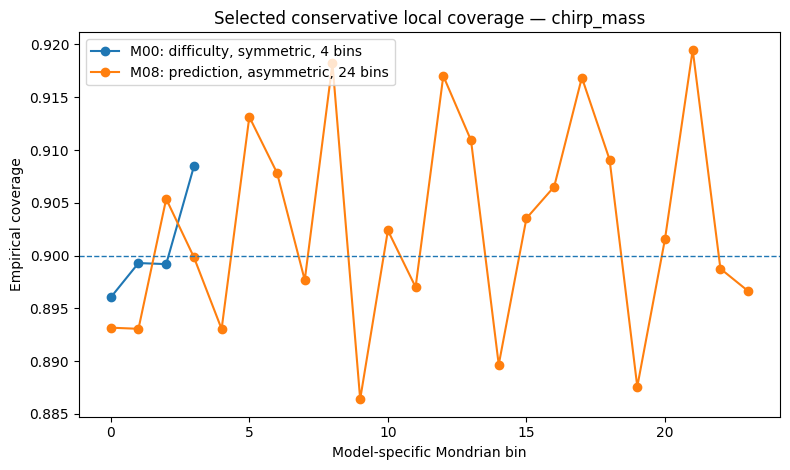

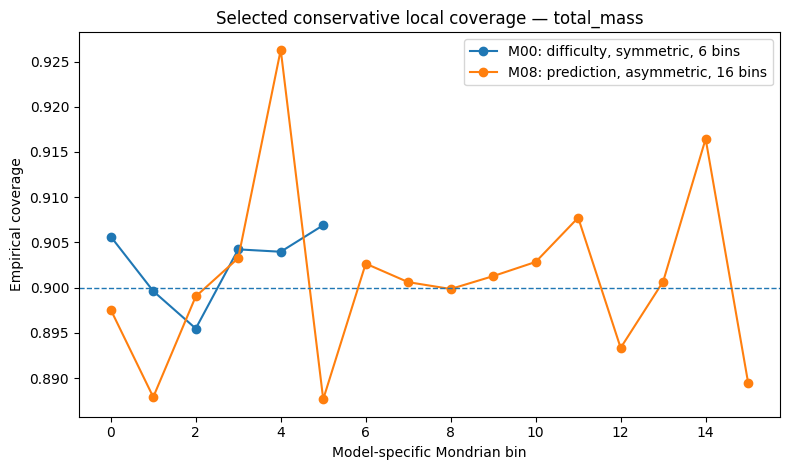

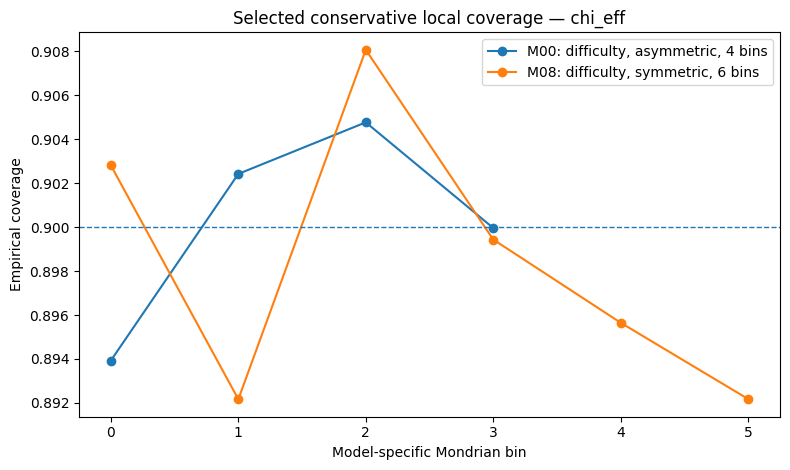

In [17]:
def selected_result_row(model_id, label):
    return selection_df[
        (selection_df["model"] == model_id)
        & (selection_df["label"] == label)
        & (selection_df["final_policy"] == "conservative")
    ].iloc[0]


for label in label_names:
    label_idx = label_names.index(label)

    plt.figure(figsize=(8.0, 4.8))

    for model_id in ["M00", "M08"]:
        row = selected_result_row(model_id, label)
        key = (
            model_id,
            row["taxonomy_mode"],
            row["interval_mode"],
            int(row["n_bins"]),
        )
        result = all_results[key]
        metrics = result.metrics

        coverage = metrics["coverage_per_bin"][:, label_idx]
        counts = metrics["counts_per_bin"][:, label_idx]
        x = np.arange(len(coverage))

        plt.plot(
            x,
            coverage,
            marker="o",
            label=(
                f"{model_id}: {row['taxonomy_mode']}, "
                f"{row['interval_mode']}, {int(row['n_bins'])} bins"
            ),
        )

    plt.axhline(CONFIDENCE_LEVEL, linestyle="--", linewidth=1)
    plt.xlabel("Model-specific Mondrian bin")
    plt.ylabel("Empirical coverage")
    plt.title(f"Selected conservative local coverage — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 13. Save comparison tables

In [18]:
OUTPUT_DIR = RESULTS_DIR / "mondrian_M00_vs_M08"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tables = {
    "global_conformal.csv": global_conformal_df,
    "global_conformal_deltas.csv": global_conformal_delta_df,
    "mondrian_summary_all.csv": summary_df,
    "matched_configurations.csv": matched_df,
    "matched_grid_summary.csv": matched_grid_summary_df,
    "selected_configurations.csv": selection_df,
    "selected_configuration_comparison.csv": selected_comparison_df,
    "top_candidates.csv": top_candidates_df,
    "decision_table.csv": decision_df,
}

for filename, dataframe in tables.items():
    path = OUTPUT_DIR / filename
    dataframe.to_csv(path, index=False)
    print("Saved:", path)

Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/mondrian_M00_vs_M08/global_conformal.csv
Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/mondrian_M00_vs_M08/global_conformal_deltas.csv
Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/mondrian_M00_vs_M08/mondrian_summary_all.csv
Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/mondrian_M00_vs_M08/matched_configurations.csv
Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/mondrian_M00_vs_M08/matched_grid_summary.csv
Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/mondrian_M00_vs_M08/selected_configurations.csv
Saved: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/mondrian_M00_vs_M08/selected_configuration_comparison.csv
Saved: /data/vserrano/cbc_pe_data/results/bbh

## Final decision

### Global conformal control

The improvement in point-estimation accuracy obtained with M08 translates directly into more efficient global conformal intervals. Relative to M00, M08 reduces the median physical interval width by 9.86% for chirp mass, 8.85% for total mass, and 8.45% for effective spin.

Empirical coverage remains close to the nominal 90% level. The coverage differences between M08 and M00 are −0.49 percentage points for chirp mass, −0.19 percentage points for total mass, and +0.16 percentage points for effective spin. Therefore, the narrower M08 intervals are not obtained through a material loss of global validity.

### Matched prediction-taxonomy comparison

The matched prediction-taxonomy comparison provides the cleanest controlled evidence because both models are evaluated using the same interval mode and number of bins.

For chirp mass, M08 produces narrower intervals in 60% of the valid matched configurations, with median width reductions of 2.55% for symmetric intervals and 4.30% for asymmetric intervals. The effect depends on the number of bins: M08 can be less efficient for very coarse partitions but becomes substantially narrower for several finer configurations.

For total mass, M08 is narrower in 75% of valid symmetric configurations and 87.5% of valid asymmetric configurations. The median width reduction is approximately 9–10%, while global coverage changes by less than 0.2 percentage points.

For effective spin, M08 is narrower in every valid matched configuration. Median width reductions are 8.80% for symmetric intervals and 7.48% for asymmetric intervals, with a small increase in global coverage. This is the strongest and most consistent Mondrian improvement.

### Difficulty-taxonomy comparison

The difficulty-based comparison evaluates the complete model-dependent system because M00 and M08 use different embeddings.

M08 remains more efficient in most valid configurations for the mass targets, although the width reductions are smaller and more variable than under the prediction taxonomy. For effective spin, M08 is narrower in all valid difficulty-based configurations, with median reductions of approximately 7.7%.

These results indicate that the M08 embedding supports a particularly useful difficulty representation for effective spin. For the mass parameters, the current k-nearest-neighbour difficulty estimator does not exploit the full point-estimation gain of M08 and may require further refinement.

### Selected conservative and efficient systems

For total mass, the selected conservative M08 system reduces the median width by 0.97% and the q95 width by 18.95%, while retaining zero bins below the two-sigma local-coverage tolerance.

For effective spin, the selected conservative M08 system reduces the median width by 11.54% and the q95 width by 9.12%, also with zero bins below the two-sigma tolerance. The efficient M08 system additionally reduces the number of locally undercovered bins from three to one.

For chirp mass, the selected conservative M08 configuration has a 12.22% larger median width than the selected M00 configuration, although its q95 width is 15.25% lower. The independently selected systems use substantially different taxonomies and bin counts, so this result does not contradict the matched-grid evidence. It shows that the current conservative selection rule trades a larger typical M08 interval for a substantially smaller upper width tail and finer local adaptation.

### Adoption decision

M08 is adopted as the new operational baseline for both point prediction and conformal analysis.

The decision is supported by:

1. substantially lower point-estimation errors;
2. global conformal intervals that are approximately 8–10% narrower at comparable coverage;
3. generally narrower matched prediction-based Mondrian intervals;
4. strong and fully consistent gains for effective spin;
5. robust improvements for total mass;
6. preserved local validity in the selected conservative systems.

The only important qualification concerns chirp mass. M08 improves global conformal efficiency and most matched Mondrian comparisons, but the current conservative selection policy chooses a configuration with a larger median width than the selected M00 system. This should be treated as a configuration-selection issue rather than evidence against the M08 predictor. The chirp-mass taxonomy and selection objective should therefore be reviewed before freezing the final Mondrian configuration.

M00 will be retained as the historical reference model, while subsequent conformal experiments will use M08 as the predictor baseline.
